In [26]:
import pandas as pd
import spacy

# NLP Today — Session 1: PoS Tagging and Constituency Parsing


| Notebook section | Report section | Question it answers |
|---|---|---|
| Part 1 — Manual analysis | First part | What tags and what grammar do *we* propose, and what trees do they produce? |
| Part 2 — Automatic analysis | Second part | What do spaCy / sciSpaCy produce, how good is it, and how do their errors propagate to parsing? |
| Part 3 — Observations | Third part | What do we conclude from the comparison? |


## 0. Dataset

The six sentences of the assignment, reproduced **verbatim, punctuation included**.

- four from the general domain (chosen for their syntactic ambiguity)
- two from specialty domains (biology and astronomy)

**Manual gold-standard PoS annotation**, using the Universal Dependencies tagset.(<https://universaldependencies.org/u/pos/>).

In [27]:
# The six sentences exactly as given in the assignment (punctuation included).
#   Sentence : the raw string, fed to spaCy / sciSpaCy
#   Tokens   : our own tokenisation, one token per gold tag
#   Pos      : the manual annotation, restricted to the 10 tags allowed by the brief
data = pd.read_csv("data/sentences.csv", sep=";")
data["n_tokens"] = data["Tokens"].str.split().str.len()
data[["Domain", "Sentence", "n_tokens"]]

,Domain,Sentence,n_tokens
0,General,The cat sat on the couch.,7
1,General,Time flies like an arrow.,6
2,General,The spy saw the cop with the telescope.,9
3,General,The spy saw the cop with the revolver.,9
4,Specialty,Arabidopsis thaliana seedlings exhibit longer ...,21
5,Specialty,A spectrogram of PSN J10354824+3900279 obtaine...,25


# Part 1 — Manual analysis

## 1.1 Gold-standard PoS annotation

The table below is the reference against which both automatic taggers will be scored in Part 2.
Three decisions were not obvious, and we record why we made them:

* **`Arabidopsis thaliana` → `PROPN PROPN`.** We treated the binomial as a name, not a description,
  and tagged both tokens alike — including the lowercase *thaliana*, since a multiword name carries
  the tag across all of its tokens. The competing reading is that a species is a *kind* and so a
  common noun; we return to it in Part 3.

* **`longer` → `ADJ`.** In *exhibit longer hypocotyls* it modifies the noun *hypocotyls*, not the
  verb, so we read it as a comparative adjective rather than an adverb.

* **`they`, `which`, `this` → `PRON`.** Each stands in for a noun phrase instead of introducing one;
  we reserved `DET` for the determiner slot (*which seedlings*, *this temperature*), where a noun
  follows.

In [28]:
# GOLD   : sentence -> list of gold PoS tags
# TOKENS : sentence -> our tokenisation
GOLD, TOKENS = {}, {}

for _, row in data.iterrows():
    GOLD[row["Sentence"]] = row["Pos"].split()
    TOKENS[row["Sentence"]] = row["Tokens"].split()

TAGSET = ["ADJ", "ADP", "AUX", "DET", "NOUN", "NUM", "PRON", "PROPN", "PUNCT", "SCONJ",
          "SYM", "VERB"]

assert all(t in TAGSET for tags in GOLD.values() for t in tags), "gold uses a tag outside TAGSET"
assert all(len(TOKENS[s]) == len(GOLD[s]) for s in GOLD), "token / tag length mismatch"

for sentence in list(GOLD)[:4]:
    display(pd.DataFrame({"token": TOKENS[sentence], "gold_POS": GOLD[sentence]}).T)

,0,1,2,3,4,5,6
token,The,cat,sat,on,the,couch,.
gold_POS,DET,NOUN,VERB,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5
token,Time,flies,like,an,arrow,.
gold_POS,NOUN,VERB,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8
token,The,spy,saw,the,cop,with,the,telescope,.
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8
token,The,spy,saw,the,cop,with,the,revolver,.
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT


## 1.2 The grammar

The assignment restricts the non-terminals to `S`, `NP`, `VP` and `PP`, and the CYK implementation
requires **Chomsky Normal Form**: 
- `A -> B C` (two non-terminals)
- `A -> tag` (pre-terminal rule ).

We use **one single grammar for the whole general-domain subset** (not one grammar per sentence):
a grammar tailored to each individual sentence would parse everything trivially and would tell us
nothing about ambiguity, which is precisely what we want to observe.

Two design decisions are worth stating explicitly, because both fix problems of our first version:

1. **`NP -> NOUN` (bare noun) is necessary.** Without it, *Time flies like an arrow* has **no parse
   at all**: `Time` alone cannot be an `NP`, so the axiom `S -> NP VP` never applies. This was the
   silent failure of our first grammar.
2. **`VP -> VERB` (unary) must be removed.** With it, *The cat sat on the couch* returns **two
   identical analyses** (one via `VP -> VERB PP`, one via `VP -> VP PP` with `VP -> VERB`). That is
   *spurious* ambiguity — an artefact of redundant rules, not a real linguistic ambiguity — and it
   pollutes the reading of the results.

The two rules that generate **genuine** ambiguity are kept on purpose:
`VP -> VP PP` (the PP modifies the verb) and `NP -> NP PP` (the PP modifies the noun).

In [29]:
G_CORE = [
    # axiom
    ("S",  ("NP", "VP")),
    ("S",  ("S", "PUNCT")),       # sentence-final full stop

    # noun phrases
    ("NP", ("DET", "NOUN")),
    ("NP", ("NOUN", "NOUN")),
    ("NP", ("NP", "PP")),         # AMBIGUITY: the PP modifies the noun / the cop has the telescope
    ("NP", ("NOUN",)),            # bare noun as NP  (fixes "Time flies like an arrow")

    # verb phrases
    ("VP", ("VERB", "NP")),
    ("VP", ("VERB", "PP")),
    ("VP", ("VP", "PP")),         # AMBIGUITY: the PP modifies the verb / the spy used the telescope

    # prepositional phrases
    ("PP", ("ADP", "NP")),        # on the couch, with the telescope

] + [(tag, (tag,)) for tag in TAGSET]   # pre-terminal rules, one per allowed tag

In [30]:
def parse(grammar, tokens, pos_lists, axiom="S"):
    '''Run CYK and keep only the trees rooted in the axiom.'''
    cyk = CYK(grammar)
    trees = cyk(pos_lists, tokens)

    approved_trees = []
    for possible_tree in trees:
        if possible_tree.type == axiom:
            approved_trees.append(possible_tree)

    return approved_trees


def parse_report(grammar, sentences, gold=GOLD, show_trees=True, max_trees=2): #GOLD is a dictionary mapping sentences to their gold POS tags {sentence: [POS tags]}
    '''Parse a list of sentences and return a one-row-per-sentence summary.'''
    rows = []
    for sentence in sentences:
        tokens = TOKENS[sentence]
        pos_tags = [[t] for t in gold[sentence]]
        trees = parse(grammar, tokens, pos_tags)
        rows.append({"Sentence": sentence, "n_parses_by_CYK": len(trees)})
        if show_trees:
            print("=" * 100)
            print(sentence, f"  ->  {len(trees)} parse(s)")
            for i, tree in enumerate(trees[:max_trees], 1):
                print(f"\n--- analysis {i} ---")
                print(tree)
            if len(trees) > max_trees:
                print(f"... {len(trees) - max_trees} further analyses not shown")
    return pd.DataFrame(rows)

### Parsing the general-domain sentences

In [31]:
from src.cyk import CYK

general = data.loc[data["Domain"] == "General", "Sentence"].tolist()
core_summary = parse_report(G_CORE, general, max_trees=3)
core_summary

The cat sat on the couch.   ->  1 parse(s)

--- analysis 1 ---
S
----S
--------NP
------------DET - The
------------NOUN - cat
--------VP
------------VERB - sat
------------PP
----------------ADP - on
----------------NP
--------------------DET - the
--------------------NOUN - couch
----PUNCT - .


Time flies like an arrow.   ->  1 parse(s)

--- analysis 1 ---
S
----S
--------NP - Time
--------VP
------------VERB - flies
------------PP
----------------ADP - like
----------------NP
--------------------DET - an
--------------------NOUN - arrow
----PUNCT - .


The spy saw the cop with the telescope.   ->  2 parse(s)

--- analysis 1 ---
S
----S
--------NP
------------DET - The
------------NOUN - spy
--------VP
------------VERB - saw
------------NP
----------------NP
--------------------DET - the
--------------------NOUN - cop
----------------PP
--------------------ADP - with
--------------------NP
------------------------DET - the
------------------------NOUN - telescope
----PUNCT - .



--

,Sentence,n_parses_by_CYK
0,The cat sat on the couch.,1
1,Time flies like an arrow.,1
2,The spy saw the cop with the telescope.,2
3,The spy saw the cop with the revolver.,2


## 1.3 Genuine ambiguity: PP attachment

*The spy-cop sentences* returns **exactly two analyses**, and they are the two
readings a human perceives:

* `VP -> VERB NP` with `NP -> NP PP` — the telescope/revolver belongs to **the cop**.
* `VP -> VP PP` — the telescope/revolver is the **instrument of the seeing**.

***Context-free*** grammar encodes what is *structurally possible*, not what is *plausible*.
- The spy saw the cop with the telescope. The telescope belongs to the spy
- The spy saw the cop with the revolver. The revolver belongs to the cop

In [32]:
def bracket(node):
    '''Bracketed notation, the format used by the Berkeley parser (easy side-by-side comparison).'''
    if node.left is None and node.right is None:
        return f"({node.type} {node.word})"
    children = [bracket(c) for c in (node.left, node.right) if c is not None]
    return f"({node.type} {' '.join(children)})"

In [33]:
for sentence in general[2:4]:
    print("=" * 100)
    print(sentence)
    postags_sentence = [[t] for t in GOLD[sentence]]
    for i, tree in enumerate(parse(G_CORE, TOKENS[sentence], postags_sentence)):
        print(f"  analysis {i}: {bracket(tree)}")

The spy saw the cop with the telescope.
  analysis 0: (S (S (NP (DET The) (NOUN spy)) (VP (VERB saw) (NP (NP (DET the) (NOUN cop)) (PP (ADP with) (NP (DET the) (NOUN telescope)))))) (PUNCT .))
  analysis 1: (S (S (NP (DET The) (NOUN spy)) (VP (VP (VERB saw) (NP (DET the) (NOUN cop))) (PP (ADP with) (NP (DET the) (NOUN telescope))))) (PUNCT .))
The spy saw the cop with the revolver.
  analysis 0: (S (S (NP (DET The) (NOUN spy)) (VP (VERB saw) (NP (NP (DET the) (NOUN cop)) (PP (ADP with) (NP (DET the) (NOUN revolver)))))) (PUNCT .))
  analysis 1: (S (S (NP (DET The) (NOUN spy)) (VP (VP (VERB saw) (NP (DET the) (NOUN cop))) (PP (ADP with) (NP (DET the) (NOUN revolver))))) (PUNCT .))


## 1.4 Several candidate PoS per token

The CYK implementation accepts **a list of candidate tags per token**, which the assignment
explicitly asks us to exploit ("*considering different possible pos for each words*").

*Time flies like an arrow* is the canonical case. If we allow `flies` to be `VERB` **or** `NOUN`
and `like` to be `ADP` **or** `VERB`, the parser returns the two famous readings — the aphorism and
the entomological one (*"time flies" are a kind of insect, and they like an arrow*) — from a single
run. This is ambiguity **imported from the tagging level**, as opposed to the structural ambiguity
of section 1.3.

In [34]:
sentence = "Time flies like an arrow."
tokens = TOKENS[sentence]

print("Gold tagging (single tag per token):")
for tree in parse(G_CORE, tokens, [[t] for t in GOLD[sentence]]):
    print("  ", bracket(tree))

print("\nAmbiguous tagging (flies = VERB|NOUN, like = ADP|VERB):")
ambiguous = [["NOUN"], ["VERB", "NOUN"], ["ADP", "VERB"], ["DET"], ["NOUN"], ["PUNCT"]]
for tree in parse(G_CORE, tokens, ambiguous):
    print("  ", bracket(tree))

Gold tagging (single tag per token):
   (S (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow))))) (PUNCT .))

Ambiguous tagging (flies = VERB|NOUN, like = ADP|VERB):
   (S (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow))))) (PUNCT .))
   (S (S (NP (NOUN Time) (NOUN flies)) (VP (VERB like) (NP (DET an) (NOUN arrow)))) (PUNCT .))


## 1.5 Specialty domains: the cost of coverage

`G_CORE` was written for the general-domain sentences and it works there. This section asks what
happens when the *same* grammar meets the two scientific sentences, and what it costs to make them
parse at all. Three tests, in order:

1. **`G_CORE` alone** — it returns no analysis whatsoever, and we show *why* rather than just
   observing it.
2. **`G_CORE` + the rules the specialty sentences need** — the specialty sentences parse, and we
   check whether the general-domain results are disturbed by the addition.
3. **The price** — the extended grammar is enormously ambiguous, and we identify which rules pay
   for that ambiguity.

The conclusion of this section is what justifies keeping **two grammars** rather than one.

In [35]:
# TEST 1 - can G_CORE even reach the tags the specialty sentences are made of?

specialty = data.loc[data["Domain"] == "Specialty", "Sentence"].tolist()


def reachable_symbols(grammar, axiom="S"):
    '''Symbols (non-terminals AND tags) that can appear in a derivation rooted in the axiom.

    A tag declared as a pre-terminal is useless if no binary rule ever produces the
    non-terminal above it: it is a dead end, and every sentence containing that tag
    is unparsable, however well tagged it may be.'''
    binary = [(head, rhs) for head, rhs in grammar if len(rhs) == 2]
    lexical = [(head, rhs) for head, rhs in grammar if len(rhs) == 1]

    reachable, frontier = set(), {axiom}
    while frontier:
        symbol = frontier.pop()
        if symbol in reachable:
            continue
        reachable.add(symbol)
        for head, (left, right) in binary:
            if head == symbol:
                frontier.update({left, right})
        for head, rhs in lexical:
            if head == symbol:
                reachable.add(rhs[0])
    return reachable


def n_parses(grammar, sentences, gold=GOLD):
    '''Number of trees rooted in S, one entry per sentence.'''
    return [len(parse(grammar, TOKENS[s], [[t] for t in gold[s]])) for s in sentences]


corpus_tags = sorted({tag for tags in GOLD.values() for tag in tags})
core_reach = reachable_symbols(G_CORE)

coverage = pd.DataFrame(
    {"reachable_from_S": ["yes" if tag in core_reach else "NO - dead end" for tag in corpus_tags]},
    index=corpus_tags,
)
coverage.index.name = "tag"
display(coverage.T)

print("Dead-end tags:", ", ".join(t for t in corpus_tags if t not in core_reach))

print("\nG_CORE on the specialty sentences:")
for sentence, n in zip(specialty, n_parses(G_CORE, specialty)):
    print(f"  {n} parse(s)  |  {sentence[:70]}...")

tag,ADJ,ADP,AUX,DET,NOUN,NUM,PRON,PROPN,PUNCT,SCONJ,SYM,VERB
reachable_from_S,NO - dead end,yes,NO - dead end,yes,yes,NO - dead end,NO - dead end,NO - dead end,yes,NO - dead end,NO - dead end,yes


Dead-end tags: ADJ, AUX, NUM, PRON, PROPN, SCONJ, SYM

G_CORE on the specialty sentences:
  0 parse(s)  |  Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are...
  0 parse(s)  |  A spectrogram of PSN J10354824+3900279 obtained on Dec. 19.33 UT sugge...


**Reading of test 1.** Seven of the twelve tags — `ADJ`, `AUX`, `NUM`, `PRON`, `PROPN`, `SCONJ`,
`SYM` — are declared as pre-terminals in `G_CORE` but **no binary rule ever consumes them**: `NP` is only
`DET NOUN`, `NOUN NOUN`, `NP PP` or a bare `NOUN`. So `Arabidopsis thaliana` (`PROPN PROPN`) cannot
become an `NP` under any derivation, and neither can *they* or *this*.

The specialty sentences are therefore not *difficult* for `G_CORE`, they are **unreachable**: the
result is `0` parses.

In [36]:
# TEST 2 - a first, deliberately naive extension: add whatever the two specialty
# sentences need, without yet worrying about how ambiguous the result becomes.

G_EXTRA = [
    # the dead-end tags finally become noun phrases
    ("NP", ("PROPN",)),            # Arabidopsis, UT, Ia
    ("NP", ("PRON",)),             # they, which, this
    ("NP", ("NUM",)),              # 3900279, 0.044
    ("PP", ("PUNCT", "NP")),       # the "-" of type-Ia, the comma before a relative clause
    ("PP", ("SYM", "NP")),         # the "+" of J10354824+3900279

    # nominal compounds and pre-modifiers
    ("NP", ("PROPN", "PROPN")),    # Arabidopsis thaliana / PSN J10354824
    ("NP", ("PROPN", "NP")),
    ("NP", ("NUM", "PROPN")),      # 19.33 UT
    ("NP", ("ADJ", "NOUN")),       # longer hypocotyls
    ("NP", ("ADJ", "NP")),         # high ambient temperature (stacked ADJ)
    ("NP", ("NP", "NOUN")),        # Arabidopsis thaliana seedlings
    ("NP", ("NP", "PROPN")),       # a type Ia
    ("NP", ("NP", "NUM")),         # redshift z 0.044

    # verbal constructions absent from the general domain
    ("VP", ("AUX", "VP")),         # are grown     (passive)
    ("VP", ("AUX", "NP")),         # is a type Ia  (copula)

    # clause-level glue. The assignment restricts the non-terminals to S/NP/VP/PP, so we
    # have no SBAR available: a subordinate clause has to be smuggled in as a PP.
    ("PP", ("SCONJ", "S")),        # when ... / that ...
    ("NP", ("NP", "S")),           # which is defined as thermomorphogenesis
    ("NP", ("NP", "VP")),          # obtained on Dec. 19.33 UT   (reduced relative)
]

G_SPEC_V0 = G_CORE + G_EXTRA

comparison = pd.DataFrame({
    "Domain": ["General"] * len(general) + ["Specialty"] * len(specialty),
    "G_CORE": n_parses(G_CORE, general + specialty),
    "G_SPEC_V0": n_parses(G_SPEC_V0, general + specialty),
}, index=[s[:45] for s in general + specialty])
comparison.index.name = "Sentence"

display(comparison)

before = comparison.loc[comparison["Domain"] == "General", "G_CORE"]
after = comparison.loc[comparison["Domain"] == "General", "G_SPEC_V0"]
print(f"\nGeneral-domain parse counts unchanged by the added rules: {before.equals(after)}")

,Domain,G_CORE,G_SPEC_V0
Sentence,,,
The cat sat on the couch.,General,1,1
Time flies like an arrow.,General,1,1
The spy saw the cop with the telescope.,General,2,2
The spy saw the cop with the revolver.,General,2,2
Arabidopsis thaliana seedlings exhibit longer,Specialty,0,3364
A spectrogram of PSN J10354824+3900279 obtain,Specialty,0,30960



General-domain parse counts unchanged by the added rules: True


**Reading of test 2.** Two things happen at once.

The specialty sentences **do** parse now — so the coverage problem is solved. And the
general-domain counts are **exactly the ones of section 1.2** (`1, 1, 2, 2`): the added rules did
*not* corrupt them. The reason is that the general sentences contain only `DET`, `NOUN`, `VERB`,
`ADP` and a final `PUNCT`, so almost every new rule requires a tag that never occurs there and can
never fire — even the rules built purely from non-terminals (`NP -> NP VP`, `NP -> NP S`), because
a full-span `NP` is rejected by the `axiom="S"` filter and no internal `NP`+`VP` adjacency exists.

This is worth stating carefully: it is a property **of this corpus**, not a general guarantee. A
single adjective in a general-domain sentence would be enough for the two rule sets to start
interacting.

So merging is not dangerous *here*. The argument for two grammars has to come from somewhere else —
and the parse counts of the specialty column already show where.

In [37]:
# TEST 3a - coverage is bought with ambiguity. Which rules pay for it?
# Remove each added rule in turn and see what happens to the two specialty sentences.

baseline = n_parses(G_SPEC_V0, specialty)

ablation = []
for rule in G_EXTRA:
    without = n_parses([r for r in G_SPEC_V0 if r != rule], specialty)
    ablation.append({
        "rule removed": f"{rule[0]} -> {' '.join(rule[1])}",
        "biology": without[0],
        "astronomy": without[1],
        "load-bearing": "yes" if 0 in without else "",
    })

ablation = pd.DataFrame(ablation).set_index("rule removed")
ablation = ablation.sort_values(["biology", "astronomy"], ascending=False)
ablation.loc["- nothing removed (full G_SPEC_V0) -"] = [baseline[0], baseline[1], ""]

display(ablation)

,biology,astronomy,load-bearing
rule removed,,,
NP -> NUM PROPN,3364,25049,
NP -> NUM,3364,0,yes
PP -> SYM NP,3364,0,yes
NP -> NP NUM,3364,0,yes
VP -> AUX NP,3364,0,yes
NP -> PROPN PROPN,2804,23790,
NP -> NP PROPN,2804,6562,
NP -> NP S,2678,21654,
NP -> PROPN,1327,134,


In [38]:
# TEST 3b - is that ambiguity linguistic, or is it an artefact of the rules?
# One flat noun phrase, parsed on its own.

fragment = ["Arabidopsis", "thaliana", "seedlings"]
fragment_tags = [["PROPN"], ["PROPN"], ["NOUN"]]

trees = parse(G_SPEC_V0, fragment, fragment_tags, axiom="NP")
print(f'"{" ".join(fragment)}"  ->  {len(trees)} NP derivations for ONE reading:\n')
for i, tree in enumerate(trees, 1):
    print(f"  {i}. {bracket(tree)}")

"Arabidopsis thaliana seedlings"  ->  5 NP derivations for ONE reading:

  1. (NP (PROPN Arabidopsis) (NP (PROPN thaliana) (NP seedlings)))
  2. (NP (PROPN Arabidopsis) (NP (NP thaliana) (NOUN seedlings)))
  3. (NP (NP (PROPN Arabidopsis) (PROPN thaliana)) (NOUN seedlings))
  4. (NP (NP (PROPN Arabidopsis) (NP thaliana)) (NOUN seedlings))
  5. (NP (NP (NP Arabidopsis) (PROPN thaliana)) (NOUN seedlings))


**Reading of test 3, and the conclusion of this section.**

The extended grammar parses the biology sentence **3364** ways and the astronomy sentence **30960**
ways. Test 3b shows what those numbers are made of: `Arabidopsis thaliana seedlings` alone has
**five** derivations, and all five mean the same thing. `NP -> PROPN`, `NP -> PROPN PROPN`,
`NP -> PROPN NP` and `NP -> NP NOUN` each offer a different way of bracketing the same flat
sequence, and every such choice multiplies with every other choice made elsewhere in the sentence.

This is **spurious ambiguity** — exactly the phenomenon that made us delete `VP -> VERB` in section
1.2, but now combinatorial rather than doubled. It is not the genuine PP-attachment ambiguity of
section 1.3, and it must not be reported as if it were.

The ablation table separates the two kinds of rule:

* **load-bearing** rules (removing one drops a sentence to `0`) — `PP -> SCONJ S` and `NP -> PRON`
  for both sentences; `NP -> ADJ NP` and `VP -> AUX VP` for the biology sentence; `NP -> NUM`,
  `NP -> NP NUM`, `VP -> AUX NP`, `PP -> PUNCT NP` and `PP -> SYM NP` for the astronomy one. These encode real
  constructions: stacked pre-modifiers, passives, copulas, pronominal subjects, relative and
  subordinate clauses, and the `+` and `-` joiners.
* **redundant** rules, which only add derivations of things already derivable.

**Why two grammars.** Not because a merged grammar would produce nonsense on the general sentences —
test 2 shows it does not. The reason is that the two grammars are measuring instruments operating in
completely different regimes. In `G_CORE`, "2 parses" is a *meaningful* number: it means two genuine
readings, which is the entire result of section 1.3. In a broad-coverage grammar, "30960 parses"
means almost nothing except that the rule set is redundant. Keeping them separate is what lets us
report the contrast — a tight grammar buys interpretable ambiguity, a broad-coverage grammar buys
reach and pays in spurious ambiguity — and that contrast *is* the cost of coverage.

`G_SPEC_V0` is a *demonstration* grammar, built to expose the problem rather than to be used. The
grammar actually used in section 2.3 (`G_SPEC`) is built there from this lesson: it keeps the
load-bearing rules and removes the redundant bracketings, bringing the two sentences down to
**354** and **2681** analyses.

# Part 2 — Automatic analysis

## 2.1 Automatic PoS tagging: spaCy vs sciSpaCy

* **`en_core_web_sm`** — small model, trained on **general-domain** web text
* **`en_core_sci_sm`** —  small model, trained on **biomedical / scientific** text.

Initial hypothesis: the general model should win on sentences 1–4 and the scientific model on sentences 5–6. Section 2.2 tests that expectation.

In [39]:
spacy_models = {"web_sm": "en_core_web_sm", "sci_sm": "en_core_sci_sm"}

# predictions      : model -> sentence -> list of predicted PoS tags
# model_tokens     : model -> sentence -> the model's OWN tokenisation
# Both are needed: a model whose tokenisation differs from ours cannot be compared token by token.
predictions = {name: {} for name in spacy_models}
model_tokens = {name: {} for name in spacy_models}

for model in spacy_models:
    nlp = spacy.load(spacy_models[model])
    for sentence in data["Sentence"]:
        doc = nlp(sentence)
        predictions[model][sentence] = [token.pos_ for token in doc]
        model_tokens[model][sentence] = [token.text for token in doc]

# Where does each tokeniser disagree with ours?
alignment = pd.DataFrame({
    "our tokens": [len(TOKENS[s]) for s in data["Sentence"]],
    **{f"{m} tokens": [len(model_tokens[m][s]) for s in data["Sentence"]] for m in spacy_models},
}, index=[s[:45] for s in data["Sentence"]])
alignment["comparable"] = [
    all(len(model_tokens[m][s]) == len(TOKENS[s]) for m in spacy_models) for s in data["Sentence"]]
display(alignment)

for sentence in data["Sentence"]:
    frame = {"token": TOKENS[sentence], "gold_POS": GOLD[sentence]}
    for model in spacy_models:
        pred = predictions[model][sentence]
        frame[f"{model}_POS"] = pred if len(pred) == len(TOKENS[sentence]) else ["-"] * len(TOKENS[sentence])
    display(pd.DataFrame(frame).T)

,our tokens,web_sm tokens,sci_sm tokens,comparable
The cat sat on the couch.,7,7,7,True
Time flies like an arrow.,6,6,6,True
The spy saw the cop with the telescope.,9,9,9,True
The spy saw the cop with the revolver.,9,9,9,True
Arabidopsis thaliana seedlings exhibit longer,21,21,21,True
A spectrogram of PSN J10354824+3900279 obtain,25,25,23,False


,0,1,2,3,4,5,6
token,The,cat,sat,on,the,couch,.
gold_POS,DET,NOUN,VERB,ADP,DET,NOUN,PUNCT
web_sm_POS,DET,NOUN,VERB,ADP,DET,NOUN,PUNCT
sci_sm_POS,DET,NOUN,VERB,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5
token,Time,flies,like,an,arrow,.
gold_POS,NOUN,VERB,ADP,DET,NOUN,PUNCT
web_sm_POS,NOUN,VERB,ADP,DET,NOUN,PUNCT
sci_sm_POS,NOUN,NOUN,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8
token,The,spy,saw,the,cop,with,the,telescope,.
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT
web_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT
sci_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8
token,The,spy,saw,the,cop,with,the,revolver,.
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT
web_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT
sci_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
token,Arabidopsis,thaliana,seedlings,exhibit,longer,hypocotyls,when,they,are,grown,...,high,ambient,temperature,",",which,is,defined,as,thermomorphogenesis,.
gold_POS,PROPN,PROPN,NOUN,VERB,ADJ,NOUN,SCONJ,PRON,AUX,VERB,...,ADJ,ADJ,NOUN,PUNCT,PRON,AUX,VERB,ADP,NOUN,PUNCT
web_sm_POS,NOUN,NOUN,NOUN,VERB,ADV,ADJ,SCONJ,PRON,AUX,VERB,...,ADJ,ADJ,NOUN,PUNCT,PRON,AUX,VERB,ADP,NOUN,PUNCT
sci_sm_POS,NOUN,NOUN,NOUN,VERB,ADV,ADJ,SCONJ,PRON,AUX,VERB,...,ADJ,ADJ,NOUN,PUNCT,DET,AUX,VERB,ADP,NOUN,PUNCT


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
token,A,spectrogram,of,PSN,J10354824,+,3900279,obtained,on,Dec.,...,is,a,type,-,Ia,at,redshift,z,0.044,.
gold_POS,DET,NOUN,ADP,PROPN,PROPN,SYM,NUM,VERB,ADP,PROPN,...,AUX,DET,NOUN,PUNCT,PROPN,ADP,NOUN,NOUN,NUM,PUNCT
web_sm_POS,DET,NOUN,ADP,PROPN,PROPN,NOUN,NUM,VERB,ADP,PROPN,...,AUX,DET,NOUN,PUNCT,NOUN,ADP,NOUN,NOUN,NUM,PUNCT
sci_sm_POS,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


## 2.2 Quantitative evaluation against the gold standard


In [40]:
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, precision_score


def evaluate_tagger(pred_by_sentence, gold_by_sentence):

    rows =[]
    all_pred =[]
    all_gold =[]
    overall_errors = Counter()

    for sentence, pred in pred_by_sentence.items():
        gold = gold_by_sentence[sentence]

        # A model that tokenises differently cannot be scored token by token.
        if len(pred) != len(gold):
            rows.append({"Sentence": sentence, "Tokens": len(gold), "Accuracy": None,
                         "F1_macro": None, "Precision_macro": None,
                         "Errors": "not comparable (tokenisation mismatch)"})
            continue
        errors = Counter(f"{gold_value} -> {pred_value}" for gold_value, pred_value in zip(gold, pred) if gold_value != pred_value)
        overall_errors.update(errors)
        all_pred.extend(pred)
        all_gold.extend(gold)

        rows.append({
            "Sentence": sentence,
            "Tokens": len(gold),
            "Accuracy": accuracy_score(gold, pred),
            "F1_macro": f1_score(gold, pred, average="macro", zero_division=0),
            "Precision_macro": precision_score(gold, pred, average="macro", zero_division=0),
            "Errors": ", ".join(f"{error} ({score})" for error, score in errors.most_common()) or "none",
        })

    if all_gold:
        rows.append({
            "Sentence": "OVERALL",
            "Tokens": len(all_gold),
            "Accuracy": accuracy_score(all_gold, all_pred),
            "F1_macro": f1_score(all_gold, all_pred, average="macro", zero_division=0),
            "Precision_macro": precision_score(all_gold, all_pred, average="macro", zero_division=0),
            "Errors": ", ".join(f"{error} ({score})" for error, score in overall_errors.most_common()) or "none",
        })

    return pd.DataFrame(rows), overall_errors


evaluations, error_counters = {}, {}

for sentence in predictions:
    frame, errors = evaluate_tagger(predictions[sentence], GOLD)
    frame.to_csv( f"results/POS_{sentence}.csv", index=False)
    evaluations[sentence], error_counters[sentence] = frame, errors
    print(f"### {sentence} ({spacy_models[sentence]})")
    display(frame)

### web_sm (en_core_web_sm)


,Sentence,Tokens,Accuracy,F1_macro,Precision_macro,Errors
0,The cat sat on the couch.,7,1.000000,1.000000,1.000000,none
1,Time flies like an arrow.,6,1.000000,1.000000,1.000000,none
2,The spy saw the cop with the telescope.,9,1.000000,1.000000,1.000000,none
3,The spy saw the cop with the revolver.,9,1.000000,1.000000,1.000000,none
4,Arabidopsis thaliana seedlings exhibit longer ...,21,0.809524,0.733333,0.726667,"PROPN -> NOUN (2), ADJ -> ADV (1), NOUN -> ADJ..."
5,A spectrogram of PSN J10354824+3900279 obtaine...,25,0.920000,0.880808,0.878788,"SYM -> NOUN (1), PROPN -> NOUN (1)"
6,OVERALL,77,0.922078,0.789672,0.805861,"PROPN -> NOUN (3), ADJ -> ADV (1), NOUN -> ADJ..."


### sci_sm (en_core_sci_sm)


,Sentence,Tokens,Accuracy,F1_macro,Precision_macro,Errors
0,The cat sat on the couch.,7,1.000000,1.000000,1.000000,none
1,Time flies like an arrow.,6,0.833333,0.760000,0.733333,VERB -> NOUN (1)
2,The spy saw the cop with the telescope.,9,1.000000,1.000000,1.000000,none
3,The spy saw the cop with the revolver.,9,1.000000,1.000000,1.000000,none
4,Arabidopsis thaliana seedlings exhibit longer ...,21,0.761905,0.636364,0.660606,"PROPN -> NOUN (2), ADJ -> ADV (1), NOUN -> ADJ..."
5,A spectrogram of PSN J10354824+3900279 obtaine...,25,NaN,NaN,NaN,not comparable (tokenisation mismatch)
6,OVERALL,52,0.884615,0.733677,0.761742,"PROPN -> NOUN (2), VERB -> NOUN (1), ADJ -> AD..."


In [41]:
# Accuracy per sentence, both models side by side -> the general vs specialty contrast in one table.

reference = next(iter(evaluations))
accuracy = pd.DataFrame({name: frame["Accuracy"].tolist() for name, frame in evaluations.items()},
                        index=evaluations[reference]["Sentence"])
accuracy.insert(0, "Domain", list(data["Domain"]) + ["-"])

accuracy.to_csv("results/POS_accuracy_comparison.csv")
accuracy.round(3)

,Domain,web_sm,sci_sm
Sentence,,,
The cat sat on the couch.,General,1.000,1.000
Time flies like an arrow.,General,1.000,0.833
The spy saw the cop with the telescope.,General,1.000,1.000
The spy saw the cop with the revolver.,General,1.000,1.000
"Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are grown under high ambient temperature, which is defined as thermomorphogenesis.",Specialty,0.810,0.762
A spectrogram of PSN J10354824+3900279 obtained on Dec. 19.33 UT suggests that this is a type-Ia at redshift z 0.044.,Specialty,0.920,NaN
OVERALL,-,0.922,0.885


In [42]:
# Which confusions does each model make?
errors_frame = pd.DataFrame(
    {name: pd.Series(counter) for name, counter in error_counters.items()}
).fillna(0).astype(int).sort_values(list(error_counters), ascending=False)

errors_frame

,web_sm,sci_sm
PROPN -> NOUN,3,2
ADJ -> ADV,1,1
NOUN -> ADJ,1,1
SYM -> NOUN,1,0
PRON -> DET,0,1
VERB -> NOUN,0,1


## 2.3 How tagging errors propagate to parsing

This is the section that joins Part 1 and Part 2. We re-run **the same grammars** — `G_CORE` for the
general sentences, `G_SPEC` for the specialty ones — changing only the tag sequence: gold, `web_sm`,
`sci_sm`. Anything that moves is caused by tagging alone.

Section 2.2 ranked the taggers by accuracy. The question here is whether that ranking predicts
anything downstream, and the answer is no: what matters is not *how many* tags a model gets wrong
but *which* ones. We isolate three distinct ways a tag error reaches the parser, and they behave
completely differently.

In [43]:
# G_SPEC - the specialty grammar, built from the lesson of section 1.5.
#
# G_SPEC_V0 there was hugely ambiguous because several rules offered competing bracketings
# of the same flat nominal. Here pre-modification is strictly RIGHT-BRANCHING (NP -> X NP)
# with a single lexical exit (NP -> X), so every flat noun phrase has exactly one derivation
# and the parses that remain are genuine attachment ambiguity, not an artefact of the rules.

G_SPEC = [
    ("S",  ("NP", "VP")),
    ("S",  ("S", "PUNCT")),        # sentence-final full stop

    # noun phrases - pre-modification, one branching direction only
    ("NP", ("DET", "NP")), ("NP", ("ADJ", "NP")), ("NP", ("NOUN", "NP")),
    ("NP", ("PROPN", "NP")), ("NP", ("NUM", "NP")),
    ("NP", ("NOUN",)), ("NP", ("PROPN",)), ("NP", ("NUM",)), ("NP", ("PRON",)),

    # noun phrases - post-modification (this is where the genuine ambiguity lives)
    ("NP", ("NP", "PP")),          # PP attachment
    ("NP", ("NP", "S")),           # relative clause
    ("NP", ("NP", "VP")),          # reduced relative: obtained on Dec. 19.33 UT
                                   #                   and: which is defined as ...

    # verb phrases
    ("VP", ("VERB", "NP")), ("VP", ("VERB", "PP")), ("VP", ("VP", "PP")),
    ("VP", ("AUX", "VP")),         # passive : are grown
    ("VP", ("AUX", "NP")),         # copula  : is a type-Ia

    # prepositional and clausal glue (no SBAR available, see 1.5)
    ("PP", ("ADP", "NP")),
    ("PP", ("SCONJ", "S")),        # when ... / that ...
    ("PP", ("PUNCT", "NP")),       # the "-" of type-Ia and the comma introducing
                                   # the relative clause
    ("PP", ("SYM", "NP")),         # the "+" of the coordinate designation J10354824+3900279
] + [(tag, (tag,)) for tag in TAGSET]


def grammar_for(sentence):
    return G_CORE if sentence in set(general) else G_SPEC


print(f"G_SPEC: {len(G_SPEC)} rules, of which {len(TAGSET)} pre-terminal")
print("Parses on the specialty sentences with gold tags:", n_parses(G_SPEC, specialty))

G_SPEC: 35 rules, of which 12 pre-terminal
Parses on the specialty sentences with gold tags: [354, 2681]


In [44]:
# The propagation table: same grammar, three different tag sequences.

rows = []
for sentence in data["Sentence"]:
    tokens = TOKENS[sentence]
    grammar = grammar_for(sentence)

    row = {"Sentence": sentence[:42],
           "grammar": "G_CORE" if sentence in set(general) else "G_SPEC"}

    taggings = {"gold": GOLD[sentence]}
    taggings.update({model: tags[sentence] for model, tags in predictions.items()})

    for model, tags in taggings.items():
        if len(tags) == len(tokens):
            row[f"n_parses_{model}"] = len(parse(grammar, tokens, [[t] for t in tags]))
        else:
            row[f"n_parses_{model}"] = None      # tokenisation mismatch, not comparable

    rows.append(row)

parses_by_tagging = pd.DataFrame(rows).set_index("Sentence")
parses_by_tagging.to_csv("results/parses_by_tagging.csv")
display(parses_by_tagging)

,grammar,n_parses_gold,n_parses_web_sm,n_parses_sci_sm
Sentence,,,,
The cat sat on the couch.,G_CORE,1,1,1.0
Time flies like an arrow.,G_CORE,1,1,0.0
The spy saw the cop with the telescope.,G_CORE,2,2,2.0
The spy saw the cop with the revolver.,G_CORE,2,2,2.0
Arabidopsis thaliana seedlings exhibit lon,G_SPEC,354,0,0.0
A spectrogram of PSN J10354824+3900279 obt,G_SPEC,2681,1318,NaN


**Most rows in this table are uninformative, and that is worth saying first.** The general-domain
sentences are short and both models tag them correctly(only one exception), so their parse counts are trivially identical
to the gold ones. Out of the twelve sentence/model pairs, one is not comparable at all (`sci_sm`
tokenises the astronomy sentence differently from us) and seven contain **no tagging error**.

Only **four** pairs actually contain an error, and they behave in two completely different ways:

| sentence | model | errors | gold | predicted |
|---|---|---|---|---|
| *Time flies like an arrow.* | `sci_sm` | 1 | 1 | **0** |
| biology | `web_sm` | 4 | 354 | **0** |
| biology | `sci_sm` | 5 | 354 | **0** |
| astronomy | `web_sm` | 2 | 2681 | **1318** |

Three collapse to nothing; the fourth keeps half of its analyses. And the number of errors does not
predict which: *one* error destroys *Time flies like an arrow.* completely, while *two* errors leave
the astronomy sentence with 1318 trees.

The next cells ask what actually separates the two cases.

In [45]:
# What exactly caused each difference?
# For every sentence a model tags imperfectly, we put ONE wrong tag back to its gold value
# and re-parse. If a single repair restores the analyses, that tag is the culprit; if none
# does, the errors only break the sentence in combination.

from itertools import combinations

for sentence in data["Sentence"]:
    for model, tags_by_sentence in predictions.items():
        pred = tags_by_sentence[sentence]
        if len(pred) != len(TOKENS[sentence]):
            continue
        wrong = [i for i, (g, p) in enumerate(zip(GOLD[sentence], pred)) if g != p]
        if not wrong:
            continue

        grammar = grammar_for(sentence)
        n_pred = len(parse(grammar, TOKENS[sentence], [[t] for t in pred]))
        n_gold = len(parse(grammar, TOKENS[sentence], [[t] for t in GOLD[sentence]]))

        print("=" * 92)
        print(f"{sentence[:70]}")
        print(f"{model}: {n_pred} parses, gold: {n_gold}\n")

        restored = False
        for i in wrong:
            repaired = list(pred)
            repaired[i] = GOLD[sentence][i]
            n = len(parse(grammar, TOKENS[sentence], [[t] for t in repaired]))
            verdict = "RESTORES the gold analyses" if n == n_gold else (
                      "no effect" if n == n_pred else f"changes the count to {n}")
            restored |= (n == n_gold)
            print(f"   put back {TOKENS[sentence][i]:>13} : {pred[i]:>5} -> {GOLD[sentence][i]:<5} "
                  f"{n:6d} parses   ({verdict})")

        if not restored:
            for size in (2, 3):
                minimal = [c for c in combinations(wrong, size)
                           if len(parse(grammar, TOKENS[sentence],
                                        [[GOLD[sentence][i] if i in c else pred[i]]
                                         for i in range(len(pred))])) == n_gold]
                if minimal:
                    names = [", ".join(TOKENS[sentence][i] for i in c) for c in minimal]
                    print(f"\n   no single repair is enough; the smallest that works is: {names[0]}")
                    break

Time flies like an arrow.
sci_sm: 0 parses, gold: 1

   put back         flies :  NOUN -> VERB       1 parses   (RESTORES the gold analyses)
Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are
web_sm: 0 parses, gold: 354

   put back   Arabidopsis :  NOUN -> PROPN      0 parses   (no effect)
   put back      thaliana :  NOUN -> PROPN      0 parses   (no effect)
   put back        longer :   ADV -> ADJ        0 parses   (no effect)
   put back    hypocotyls :   ADJ -> NOUN       0 parses   (no effect)

   no single repair is enough; the smallest that works is: longer, hypocotyls
Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are
sci_sm: 0 parses, gold: 354

   put back   Arabidopsis :  NOUN -> PROPN      0 parses   (no effect)
   put back      thaliana :  NOUN -> PROPN      0 parses   (no effect)
   put back        longer :   ADV -> ADJ        0 parses   (no effect)
   put back    hypocotyls :   ADJ -> NOUN       0 parses   (no effect)
   put back 

**What the repairs show.**

* *Time flies like an arrow.* — `flies` tagged `NOUN` instead of `VERB` is the whole story. Put it
  back and the parse returns. The sentence has no other verb, so `S -> NP VP` has nothing to build a
  `VP` from.
* **Astronomy, `web_sm`** — two errors, and they are not equal. Putting `+` back to `SYM` restores
  all 2681 analyses; putting `Ia` back to `PROPN` changes nothing at all, because `G_SPEC` lets
  `NOUN` and `PROPN` fill exactly the same slots. One error costs everything, the other is free.
* **Biology, both models** — no single repair helps. For `web_sm`, `longer` → `ADV` and
  `hypocotyls` → `ADJ` have to be corrected *together*: those two words form the object noun phrase,
  and as `ADV ADJ` it has no noun to head it. `sci_sm` needs a third, `which` → `DET`, which
  otherwise leaves the relative clause without a subject. The `PROPN` → `NOUN` errors on the
  binomial are irrelevant in both cases.

So a tag error matters when it removes something the grammar structurally needs — a verb for the
`VP`, a noun to head the `NP`, a `SYM` for the joiner. Errors that leave a usable category in place
cost nothing, however wrong they are linguistically. Counting errors tells you almost nothing:
*Time flies* dies of one, the astronomy sentence survives two, biology needs two specific ones
to fall.

In [46]:
# The clearest case: sciSpaCy tags "flies" as NOUN, and the sentence loses its verb.
sentence = "Time flies like an arrow."
print(f"Sentence: {sentence}")
for name in ["gold"] + list(predictions):
    tags = GOLD[sentence] if name == "gold" else predictions[name][sentence]
    trees = parse(G_CORE, TOKENS[sentence], [[t] for t in tags])
    print(f"{name:7s} {tags}  ->  {len(trees)} parse(s)")
    for tree in trees:
        print("        ", bracket(tree))

Sentence: Time flies like an arrow.
gold    ['NOUN', 'VERB', 'ADP', 'DET', 'NOUN', 'PUNCT']  ->  1 parse(s)
         (S (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow))))) (PUNCT .))
web_sm  ['NOUN', 'VERB', 'ADP', 'DET', 'NOUN', 'PUNCT']  ->  1 parse(s)
         (S (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow))))) (PUNCT .))
sci_sm  ['NOUN', 'NOUN', 'ADP', 'DET', 'NOUN', 'PUNCT']  ->  0 parse(s)


## 2.4 Comparison with a trained constituency parser

spaCy's own pipeline gives a **dependency** parse, not a constituency tree. The constituency parser
that plugs into spaCy is **benepar** — the Berkeley Neural Parser as a pipeline component — which we
run below; the online-demo screenshots follow for reference.

Same question as in 1.3: **where does the PP attach**, and does the answer change between
*telescope* and *revolver*?

In [49]:
# The Berkeley Neural Parser as a spaCy component. The model is a ~500 MB download, run once:
#     import benepar; benepar.download("benepar_en3")
# If it is not available, the screenshots of the online demo below serve as the reference.

try:
    import nltk
    nltk.download('punkt')
    import benepar
    benepar.download('benepar_en3')
    nlp_const = spacy.load("en_core_web_sm")
    if "benepar" not in nlp_const.pipe_names:
        nlp_const.add_pipe("benepar", config={"model": "benepar_en3"})

    for sentence in data["Sentence"]:
        doc = nlp_const(sentence)
        sent = list(doc.sents)[0]
        print("=" * 100)
        print(sentence)
        print("  benepar :", sent._.parse_string)
        if sentence in set(general):
            ours = [bracket(t) for t in parse(G_CORE, TOKENS[sentence], [[t] for t in GOLD[sentence]])]
            for i, b in enumerate(ours, 1):
                print(f"  ours {i}  : {b}")

except Exception as exc:
    print(f"benepar not run ({type(exc).__name__}: {exc}).")
    print("Falling back on the Berkeley online-demo screenshots displayed below.")

[nltk_data] Downloading package punkt to /home/alexandre/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/home/alexandre/Desktop/5year/NLP_Today/Workshop_1_NLP_Today/venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/alexandre/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package benepar_en3 to
[nltk_data]     /home/alexandre/nltk_data...
[nltk_data]   Unzipping models/benepar_en3.zip.
/home/alexandre/Desktop/5year/NLP_Today/Workshop_1_NLP_Today/venv/lib/python3.12/site-packages/nltk/downloader.py:1182: RuntimeWarning: NLTK downloader package metadata is missing SHA256 checksums; falling back to legacy MD5 verification. Consider updating your NLTK data index (or re-running the downloader) to ge

The cat sat on the couch.
  benepar : (S (NP (DT The) (NN cat)) (VP (VBD sat) (PP (IN on) (NP (DT the) (NN couch)))) (. .))
  ours 1  : (S (S (NP (DET The) (NOUN cat)) (VP (VERB sat) (PP (ADP on) (NP (DET the) (NOUN couch))))) (PUNCT .))
Time flies like an arrow.
  benepar : (S (NP (NN Time)) (VP (VBZ flies) (PP (IN like) (NP (DT an) (NN arrow)))) (. .))
  ours 1  : (S (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow))))) (PUNCT .))
The spy saw the cop with the telescope.
  benepar : (S (NP (DT The) (NN spy)) (VP (VBD saw) (NP (DT the) (NN cop)) (PP (IN with) (NP (DT the) (NN telescope)))) (. .))
  ours 1  : (S (S (NP (DET The) (NOUN spy)) (VP (VERB saw) (NP (NP (DET the) (NOUN cop)) (PP (ADP with) (NP (DET the) (NOUN telescope)))))) (PUNCT .))
  ours 2  : (S (S (NP (DET The) (NOUN spy)) (VP (VP (VERB saw) (NP (DET the) (NOUN cop))) (PP (ADP with) (NP (DET the) (NOUN telescope))))) (PUNCT .))
The spy saw the cop with the revolver.
  benepar : (S (NP (DT The) (NN sp

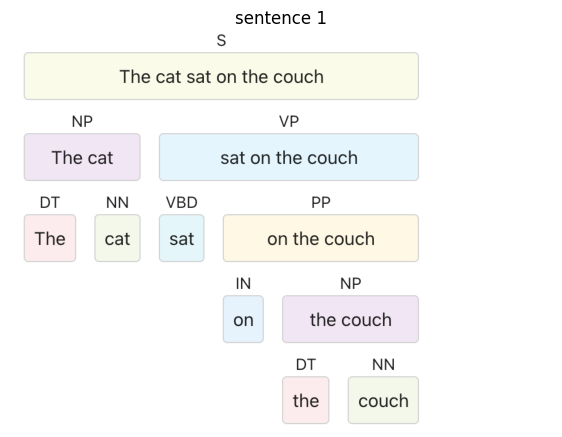

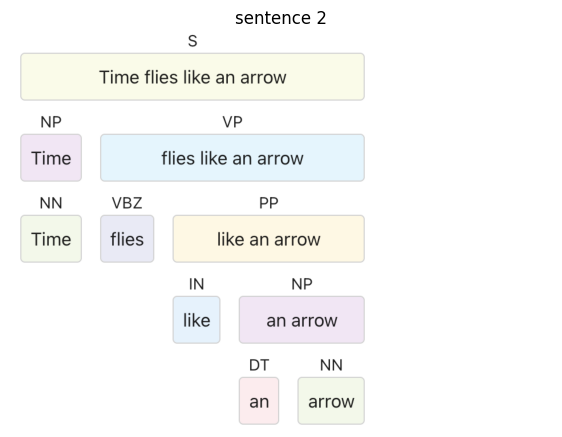

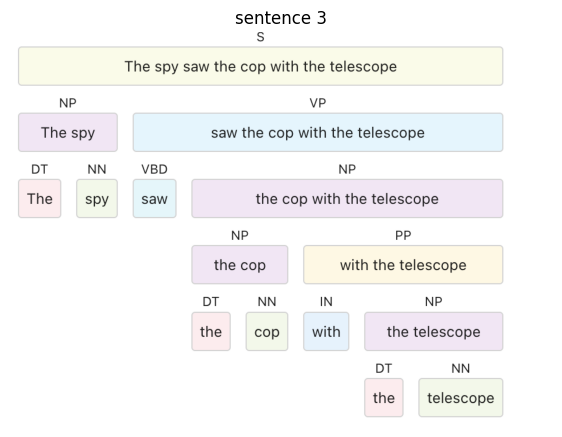

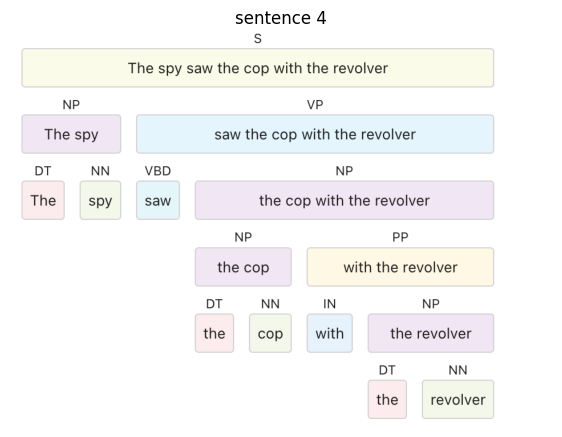

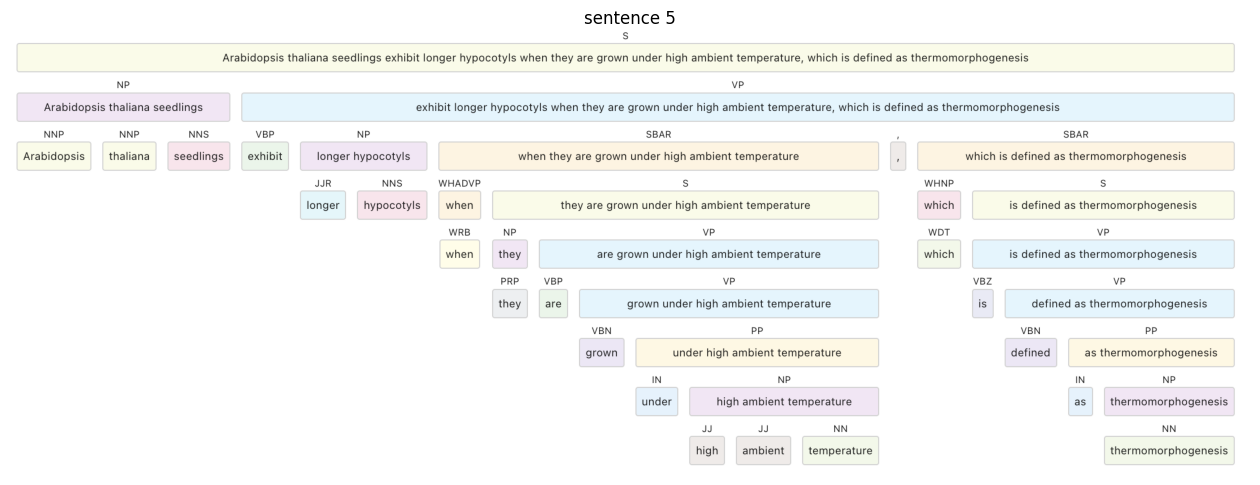

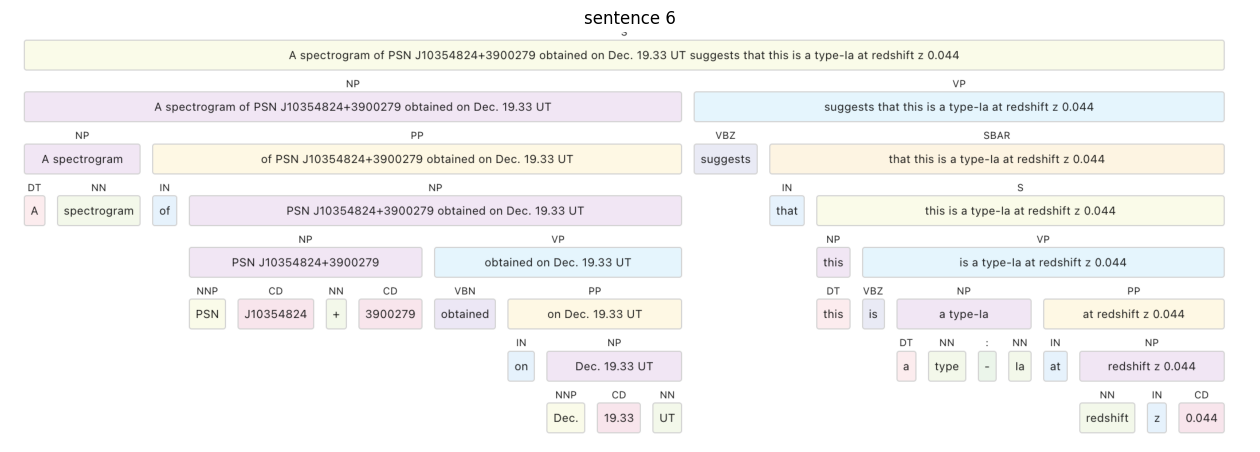

In [50]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

folder = Path("Berkeley_Neural_Parser")

for path in sorted(folder.iterdir()):

    if path.stem in {"sentence_5", "sentence_6"}:
        size = (16, 16)
    else:
        size = (7, 7)
        
    plt.figure(figsize=size)
    plt.imshow(Image.open(path))
    plt.title(path.stem.replace("_", " "))
    plt.axis("off")
    plt.show()

**Reading of 2.4.**

* **One tree, always.** We return 2 analyses per spy sentence and 354 / 2681 for the specialty ones;
  benepar returns one. It never exposes the ambiguity — on *Time flies like an arrow.* it gives only
  the aphorism reading.

* ***Telescope* and *revolver* come back with the same tree.** Benepar attaches the PP to the verb
  phrase — `(VP (VBD saw) (NP the cop) (PP with …))`, the PP sitting beside the object rather than
  inside it — which is the "the spy used it to see" reading, our `VP -> VP PP` of section 1.3. It
  makes that choice for *both* sentences, so the change of noun has no effect on the analysis. The
  online-demo screenshots above make the opposite choice, putting the PP inside the object noun
  phrase (`NP -> NP PP`, "the cop had it") — again for both sentences. Neither version varies its
  answer between *telescope* and *revolver*, which is precisely what a reader does.

* **Richer labels than we are allowed**: `SBAR` ×2, `WHADVP`, `WHNP`, `NML`, and flat n-ary rules
  (`VP -> VBD NP PP`) that are not in Chomsky Normal Form. Several of its analyses are inexpressible
  under `S/NP/VP/PP` — the limitation predicted in 1.5, confirmed from outside.

* **It supports two of our annotation decisions** against both spaCy models: `flies` is `VBZ` (verb)
  and `longer` is `JJR` (comparative *adjective*). It also attaches the relative clause low, to
  *high ambient temperature*, exactly as `G_SPEC` does.

* **It contradicts our binomial.** `Arabidopsis thaliana` comes back `NNS NN` — common nouns, siding
  with both taggers against our `PROPN PROPN`. It also reads `this` as `DT` and `J10354824` as `CD`.

# Part 3 — Observations

### 3.1 On PoS tagging

**The general-purpose model beats the biomedical one, including on the biomedical sentence.**
`en_core_web_sm` reaches **0.922** overall against **0.885** for `en_core_sci_sm`, and on the biology
sentence it leads **0.810** to **0.762**. This is counter-intuitive and it is the first thing to say:
sciSpaCy's advantage lies in biomedical tokenisation and named-entity recognition, not in PoS
tagging, whose component is trained on different treebanks with different conventions. The two
figures are not even measured on the same basis — see the tokenisation point below.

**The single biggest source of disagreement is a definitional one, not a mistake.**
`PROPN -> NOUN` is the most frequent confusion for both models (3 and 2 occurrences). It is not
carelessness: the taggers apply UD's own criterion — `PROPN` marks a *specific individual* — and are
perfectly consistent about it. `web_sm` returns `PROPN` for `PSN`, `J10354824`, `Dec.` and `UT`, all
of which name one particular object, and `NOUN` for `Arabidopsis`, `thaliana` and `Ia`, all of which
name a *kind*. Our gold uses the other criterion, the nomenclatural one: a formal Latin binomial is a
name, therefore `PROPN`. The Berkeley parser independently agrees with the taggers, labelling
*Arabidopsis thaliana* `NNS NN` — three systems against our one. The lesson for evaluation is that accuracy
against a hand-made gold standard measures the distance between two annotation conventions at least
as much as it measures tagging quality.

**Some model errors really are errors.** `longer` tagged `ADV` by both models is one: the word
modifies *hypocotyls*, so it is a comparative adjective, and the Berkeley parser's `JJR` (2.4)
supports our `ADJ`. Likewise `hypocotyls` tagged `ADJ`, `redshift` tagged `NUM` and `z` tagged
`PUNCT` by `sci_sm` are plain failures on unfamiliar vocabulary — which is precisely where a
domain-specific model was supposed to help.

**Tokenisation is part of the comparison, and it is where the specialty model differs most.**
`sci_sm` reads `type-Ia` as one token where `web_sm` and our annotation read three, producing 23
tokens against 25. The astronomy sentence therefore cannot be scored for `sci_sm` at all, and its
overall figure covers 52 tokens against `web_sm`'s 77. A model can be *incomparable* before it is
even wrong.

### 3.2 On grammars and CYK

**Ambiguity comes from two independent sources.** Structural ambiguity — the same tags bracketed
differently — gives exactly two analyses of each spy sentence (1.3). Lexical ambiguity — several
candidate tags for one token — gives the two readings of *Time flies like an arrow.* (1.4). The CYK
implementation accepts a list of tags per token, so both can be produced by the same machinery.

**A context-free grammar states what is *possible*, never what is *plausible*.** The decisive result
is that our grammar returns the *same* two trees for *…with the telescope* and *…with the revolver*,
although a human strongly prefers a different reading in each. Nothing in a CFG can express that
preference; disambiguation needs lexical and world knowledge that lives outside the formalism.

**Coverage is bought with ambiguity, and the exchange rate is brutal.** `G_CORE` cannot parse the
specialty sentences at all — seven of the twelve tags are unreachable from the axiom, so the result is
`0` and would remain `0` with a perfect tagger (1.5, test 1). A naive extension makes them parse, at
**3364** and **30960** analyses (test 2). Most of that is *spurious*: `Arabidopsis thaliana
seedlings` alone had five derivations of one single reading. Rewriting the grammar with a single
branching direction brings it down to **354** and **2681** without losing a construction. The
surviving ambiguity is genuine attachment ambiguity, and in a 25-token sentence there are simply many
places for a modifier to attach.

**Two grammars, not one — but not for the reason one would expect.** Merging the specialty rules into
`G_CORE` leaves the general-domain counts untouched (`1, 1, 2, 2`), because the added rules need tags
the general sentences do not contain. The real argument is that the two grammars measure in different
regimes: "2 parses" from `G_CORE` means *two genuine readings*, while "2681 parses" means little more
than that many attachment sites exist. Keeping them apart is what makes either number readable.

**The restriction to `S/NP/VP/PP` is itself a cost.** With no `SBAR`, subordinate clauses, the `+`
and `-` joiners and the comma before a relative clause all had to be smuggled in as `PP -> SCONJ S`,
`PP -> PUNCT NP` and `PP -> SYM NP`. Section 2.4 confirms this from the outside: on the same sentences Berkeley uses
`SBAR`, `WHNP`, `WHADVP` and `NML`, and flat n-ary rules that are not in Chomsky Normal Form.

### 3.3 On the interaction between the two — the main result

**Tagging accuracy does not predict parsing success.** Only four sentence/model pairs in our corpus
actually contain a tagging error; three of them lose *every* analysis, because a CFG is a hard
constraint and an unusable tag leaves nothing to build. The fourth is as instructive as the other
three. `web_sm` scores **0.810** on the biology sentence and
loses all 354 analyses; it scores **0.920** on the astronomy sentence and keeps **1318** of 2681. Four
accuracy points separate those two outcomes, and they explain nothing. What explains them is *where*
the errors fall:

* the most frequent confusion, `PROPN -> NOUN`, is **free** — 354 and 2681 analyses with or without
  it, because the grammar treats both tags as ordinary nominals;
* a single error on a **head** is fatal — `flies` tagged `NOUN` removes the only verb and
  *Time flies like an arrow.* drops from 1 parse to 0; `hypocotyls` tagged `ADJ` leaves the object
  noun phrase headless and kills the biology sentence on its own;
* a tag merely **outside the grammar's inventory** is equally fatal though often not wrong at all —
  `ADV` for *longer*, `CCONJ` for the `+` where UD says `SYM`.

So the model that wins on accuracy owes its lead largely to a definitional disagreement that costs
nothing downstream, while the errors that actually destroy the parse are rare, cheap-looking, and
sometimes not errors. No accuracy, precision or F1 figure distinguishes them.

**And a trained parser does not solve the problem, it hides it.** Berkeley returns one tree where we
return two, gives *telescope* and *revolver* the same analysis, and never surfaces the second reading
of *Time flies like an arrow.* It does not even hold that analysis steady: the packaged model attaches
the PP high, the online demo attaches it low, and neither distinguishes the two sentences. Our
pipeline is far weaker in coverage, but it is the one that makes the ambiguity — the actual object of
study — visible.